# Классификация жанров музыки по аудио-признакам (KNN)

**Датасет:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

**Задача:** по числовым характеристикам трека (danceability, energy, tempo и др.) определить его жанр с помощью алгоритма K ближайших соседей.

## 1. Краткая теория

KNN (K ближайших соседей) — это алгоритм ленивого обучения, который классифицирует объект по большинству голосов среди K ближайших соседей в пространстве признаков. Ключевые гиперпараметры: выбор K, метрика расстояния и масштабирование признаков.

## 2. Загрузка данных

In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
csv_path = os.path.join(path, "dataset.csv")
print("Файл:", csv_path)

Файл: C:\Users\danii\.cache\kagglehub\datasets\maharshipandya\-spotify-tracks-dataset\versions\1\dataset.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

df = pd.read_csv(csv_path)
df.shape

(114000, 21)

## 3. Первичный анализ


In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [7]:
df['track_genre'].nunique()

114

In [8]:
df['track_genre'].value_counts().head(20)

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
kids                 1000
Name: count, dtype: int64

В датасете 114 жанров — слишком много для KNN. Возьмём 6 контрастных жанров, которые отличаются по характеру звучания.

In [9]:
selected_genres = ['classical', 'metal', 'hip-hop', 'jazz', 'edm', 'country']
df = df[df['track_genre'].isin(selected_genres)].copy()

genre_names = {
    'classical': 'классика', 'metal': 'метал', 'hip-hop': 'хип-хоп',
    'jazz': 'джаз', 'edm': 'электроника', 'country': 'кантри'
}

df['track_genre'].value_counts()

track_genre
classical    1000
country      1000
edm          1000
hip-hop      1000
jazz         1000
metal        1000
Name: count, dtype: int64

## 4. Предобработка

In [10]:
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

feature_names_ru = {
    'danceability': 'танцевальность', 'energy': 'энергичность',
    'loudness': 'громкость', 'speechiness': 'речевость',
    'acousticness': 'акустичность', 'instrumentalness': 'инструментальность',
    'liveness': 'живость', 'valence': 'валентность', 'tempo': 'темп'
}

X = df[features]
y = df['track_genre']

In [11]:
X.isnull().sum()

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64

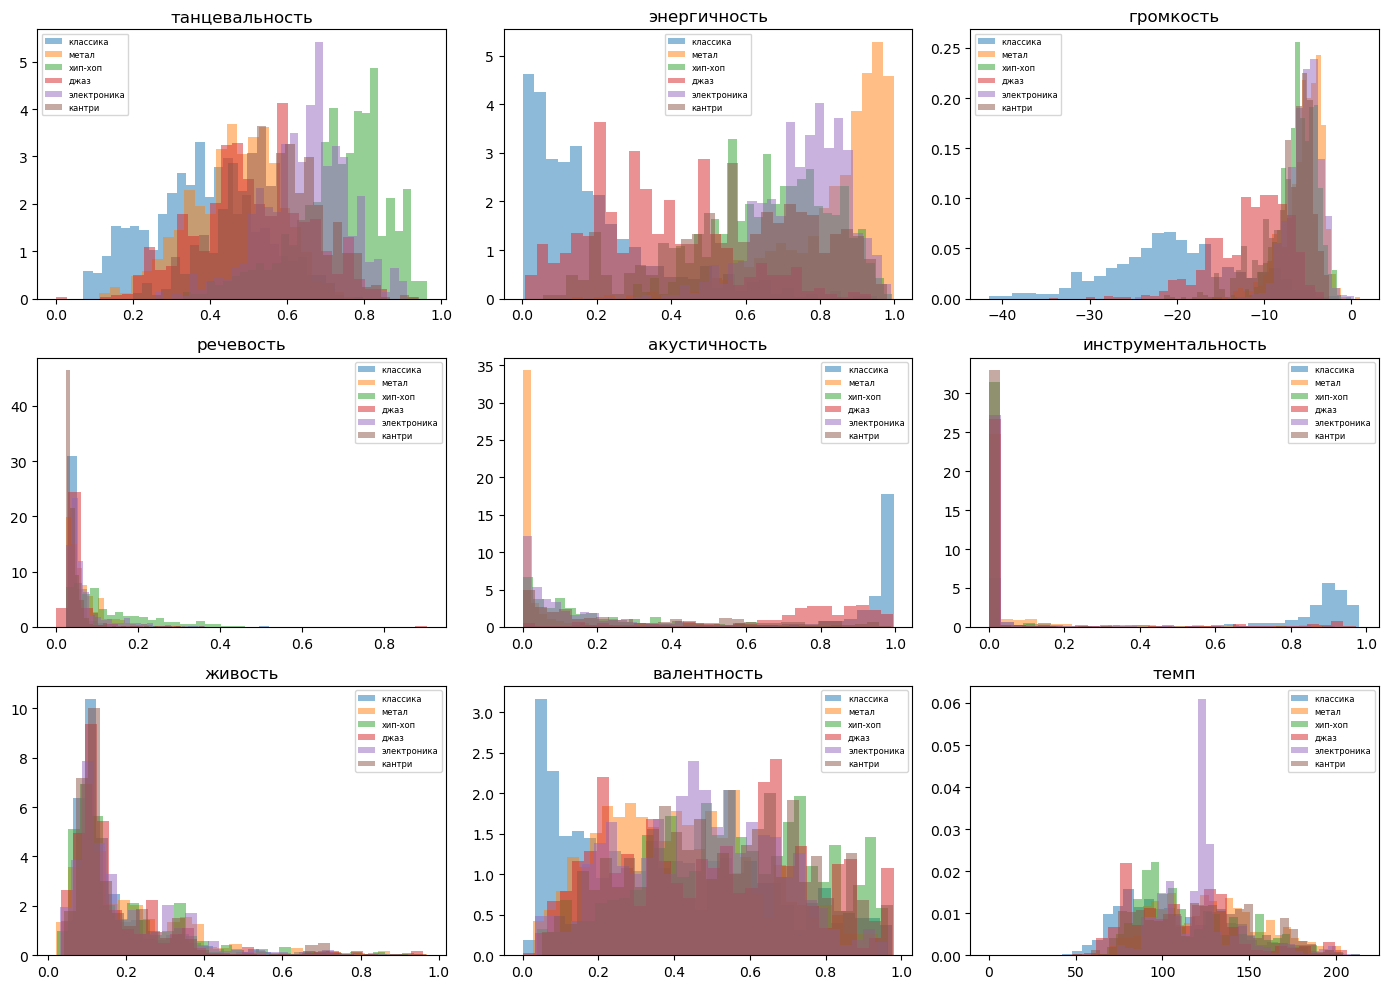

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    for genre in selected_genres:
        subset = df[df['track_genre'] == genre]
        ax.hist(subset[feat], bins=30, alpha=0.5, label=genre_names[genre], density=True)
    ax.set_title(feature_names_ru[feat])
    ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

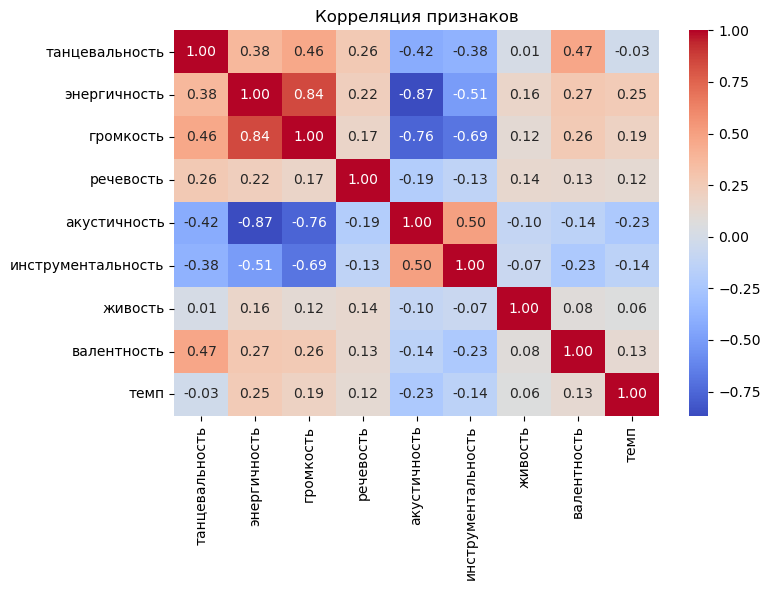

In [13]:
plt.figure(figsize=(8, 6))
corr = X.corr()
corr.index = [feature_names_ru[f] for f in corr.index]
corr.columns = [feature_names_ru[f] for f in corr.columns]
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция признаков')
plt.tight_layout()
plt.show()

### Разбиение и масштабирование

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]}, Test: {X_test_sc.shape[0]}")

Train: 4800, Test: 1200


## 5. Обучение модели

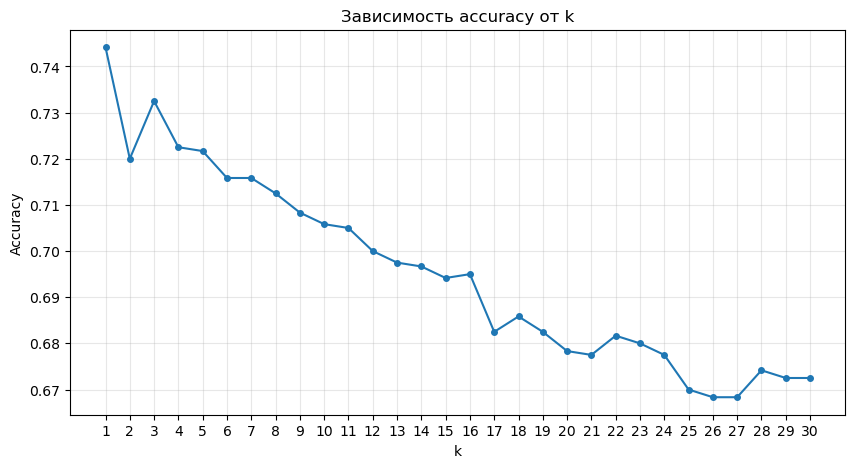

Лучший k = 1, accuracy = 0.7442


In [15]:
k_range = range(1, 31)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    scores.append(knn.score(X_test_sc, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_range, scores, marker='o', markersize=4)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_range)[np.argmax(scores)]
print(f"Лучший k = {best_k}, accuracy = {max(scores):.4f}")

При k=1 достигается лучшая accuracy (0.74). Малое значение k объясняется тем, что 6 выбранных жанров (classical, metal, hip-hop, jazz, edm, country) достаточно контрастны по аудио-признакам.

### Обучение модели с лучшим k

In [16]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)

## 6. Оценка качества

In [17]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.7442


Лучше всего классифицируется classical (F1=0.85) — у него уникальный профиль: низкая energy, высокая acousticness. Хуже всего — country (F1=0.66), который по признакам пересекается с hip-hop и edm.

Основные ошибки: country↔hip-hop и edm↔hip-hop. Эти жанры имеют схожие значения danceability и energy.

In [18]:
print(classification_report(y_test, y_pred,
                            target_names=[genre_names[g] for g in selected_genres]))

              precision    recall  f1-score   support

    классика       0.85      0.84      0.85       200
       метал       0.67      0.66      0.66       200
     хип-хоп       0.69      0.72      0.71       200
        джаз       0.75      0.66      0.70       200
 электроника       0.75      0.75      0.75       200
      кантри       0.75      0.82      0.79       200

    accuracy                           0.74      1200
   macro avg       0.74      0.74      0.74      1200
weighted avg       0.74      0.74      0.74      1200



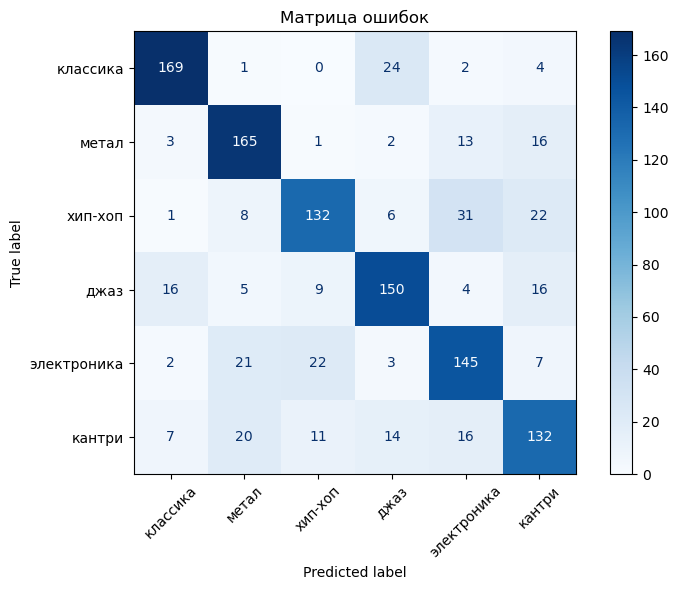

In [19]:
cm = confusion_matrix(y_test, y_pred, labels=selected_genres)
display_labels_ru = [genre_names[g] for g in selected_genres]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels_ru)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Матрица ошибок')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ошибки модели логичны: перепутанные треки действительно находятся на границе жанров по аудио-характеристикам.

### Тестовые примеры

Возьмём несколько реальных треков из тестовой выборки и посмотрим, что предсказывает модель.

In [20]:
test_df = df.loc[X_test.index].copy()
test_df['predicted'] = y_pred

examples = []
for genre in selected_genres:
    correct = test_df[(test_df['track_genre'] == genre) & (test_df['predicted'] == genre)]
    if len(correct) > 0:
        examples.append(correct.sample(1, random_state=42))

examples_df = pd.concat(examples)
features_ru = [feature_names_ru[f] for f in features]
display_df = examples_df[['artists', 'track_name', 'track_genre', 'predicted'] + features].copy()
display_df['track_genre'] = display_df['track_genre'].map(genre_names)
display_df['predicted'] = display_df['predicted'].map(genre_names)
display_df.columns = ['исполнитель', 'название', 'жанр', 'предсказание'] + features_ru
display_df

,исполнитель,название,жанр,предсказание,танцевальность,энергичность,громкость,речевость,акустичность,инструментальность,живость,валентность,темп
16058,Frédéric Chopin;Dang Thai Son,"Nocturne In C-Sharp Minor, Op. Posth.",классика,классика,0.211,0.0309,-29.185,0.0350,0.988000,0.917000,0.0685,0.206,73.820
71326,Skillet,The Resistance,метал,метал,0.483,0.9410,-3.598,0.0575,0.000526,0.000003,0.3100,0.503,156.033
51858,Burna Boy;Wizkid,B. D’OR,хип-хоп,хип-хоп,0.873,0.6580,-8.031,0.1080,0.008580,0.006100,0.0999,0.483,104.033
64270,Nat King Cole;John Legend,The Christmas Song (Chestnuts Roasting On An O...,джаз,джаз,0.226,0.3820,-9.243,0.0288,0.845000,0.000000,0.1110,0.165,81.943
30735,Rudimental;Anne-Marie;Tion Wayne,Come Over,электроника,электроника,0.797,0.6720,-6.135,0.0477,0.044200,0.002700,0.1490,0.561,131.978
19295,Kacey Musgraves,Christmas Makes Me Cry - From The Kacey Musgra...,кантри,кантри,0.506,0.2100,-12.534,0.0569,0.808000,0.000000,0.7500,0.414,104.181


In [21]:
errors = test_df[test_df['track_genre'] != test_df['predicted']]
error_sample = errors.sample(5, random_state=42)
display_err = error_sample[['artists', 'track_name', 'track_genre', 'predicted'] + features].copy()
display_err['track_genre'] = display_err['track_genre'].map(genre_names)
display_err['predicted'] = display_err['predicted'].map(genre_names)
display_err.columns = ['исполнитель', 'название', 'жанр', 'предсказание'] + features_ru
display_err

,исполнитель,название,жанр,предсказание,танцевальность,энергичность,громкость,речевость,акустичность,инструментальность,живость,валентность,темп
51371,Oliver Tree,Life Goes On,хип-хоп,кантри,0.700,0.490,-5.187,0.0760,0.186,0.000000,0.117,0.569,79.982
51046,Anirudh Ravichander,"Life of Pazham (From ""Thiruchitrambalam"")",хип-хоп,кантри,0.503,0.665,-6.302,0.0801,0.124,0.000155,0.175,0.597,174.974
19827,Riley Green,Trouble With You,кантри,хип-хоп,0.764,0.646,-6.919,0.0403,0.254,0.000000,0.113,0.434,96.041
64511,Hüsnü Arkan;Birsen Tezer,Öyle Bir Rüya,джаз,метал,0.372,0.475,-10.046,0.0298,0.142,0.000050,0.131,0.369,97.146
51280,Daler Mehndi;Hrishikesh;Neuman;FRANCO;Shazneen...,Aasman Ko Chukar,хип-хоп,электроника,0.536,0.438,-12.894,0.1030,0.119,0.000000,0.129,0.127,144.626


### Предсказание для произвольного трека

Подадим вручную характеристики условных треков и посмотрим результат.

In [22]:
# Спокойный акустический трек (ожидание: классика)
calm_track = pd.DataFrame([{
    'danceability': 0.30,       # не танцевальный
    'energy': 0.05,             # почти нет интенсивности
    'loudness': -18.0,          # очень тихий
    'speechiness': 0.04,        # почти нет речи
    'acousticness': 0.95,       # полностью акустический
    'instrumentalness': 0.80,   # без вокала
    'liveness': 0.10,           # студийная запись
    'valence': 0.25,            # меланхоличный
    'tempo': 75.0               # медленный
}])

calm_sc = scaler.transform(calm_track)
pred2 = model.predict(calm_sc)[0]
proba2 = model.predict_proba(calm_sc)[0]

print(f"Предсказанный жанр: {genre_names.get(pred2, pred2)}")
print("\nВероятности по жанрам:")
for genre, p in sorted(zip(model.classes_, proba2), key=lambda x: -x[1]):
    print(f"  {genre_names.get(genre, genre):18s} {p:.3f}")

Предсказанный жанр: классика

Вероятности по жанрам:
  классика           1.000
  кантри             0.000
  электроника        0.000
  хип-хоп            0.000
  джаз               0.000
  метал              0.000


In [23]:
# Тяжёлый агрессивный трек (ожидание: метал)
metal_track = pd.DataFrame([{
    'danceability': 0.30,       # сложный ритм, не для танцев
    'energy': 1.00,             # максимальная интенсивность
    'loudness': -5.0,           # очень громкий, сильная компрессия
    'speechiness': 0.10,        # вокал есть, но это пение/крик
    'acousticness': 0.05,       # перегруженные электрогитары
    'instrumentalness': 0.10,   # есть вокал
    'liveness': 0.10,           # студийная запись
    'valence': 0.25,            # мрачный, агрессивный
    'tempo': 130.0              # типичный темп для хэви/трэша
}])

mateal_sc = scaler.transform(metal_track)
pred2 = model.predict(mateal_sc)[0]
proba2 = model.predict_proba(mateal_sc)[0]

print(f"Предсказанный жанр: {genre_names.get(pred2, pred2)}")
print("\nВероятности по жанрам:")
for genre, p in sorted(zip(model.classes_, proba2), key=lambda x: -x[1]):
    print(f"  {genre_names.get(genre, genre):18s} {p:.3f}")

Предсказанный жанр: метал

Вероятности по жанрам:
  метал              1.000
  классика           0.000
  кантри             0.000
  электроника        0.000
  хип-хоп            0.000
  джаз               0.000
